# AdaptivePlot

`AdaptivePlot` renders adaptive comfort charts following **ASHRAE 55** or **EN 16798**. The x-axis shows the prevailing mean outdoor temperature (Tpma or Trm), the y-axis shows operative temperature. Pass the model function (`adaptive_ashrae` or `adaptive_en`) and set air speed via `set_params(v=...)`. When `v ≥ 0.6 m/s` and operative temperature exceeds 25 °C, the model applies a cooling effect that expands the upper boundary of each band.

When overlaying your own scatter data, choose `v` to match the air speed used to calculate the plotted points. If air speed varies across rows, use a representative value such as the mode or median for the chart, and treat the displayed bands as approximate. Use the per-row model acceptability outputs as the source of truth: `acceptability_80` and `acceptability_90` from `adaptive_ashrae`, or `acceptability_cat_i`, `acceptability_cat_ii`, and `acceptability_cat_iii` from `adaptive_en`.


In [1]:
import matplotlib.pyplot as plt

from pythermalcomfort.models import adaptive_ashrae, adaptive_en
from pythermalcomfort.plots.matplotlib import AdaptivePlot, RegionsConfig

## 1. ASHRAE 55 — Default Chart

With no `set_regions` call, all available bands are shown using their default colours. The dashed line marks the optimal comfort temperature.

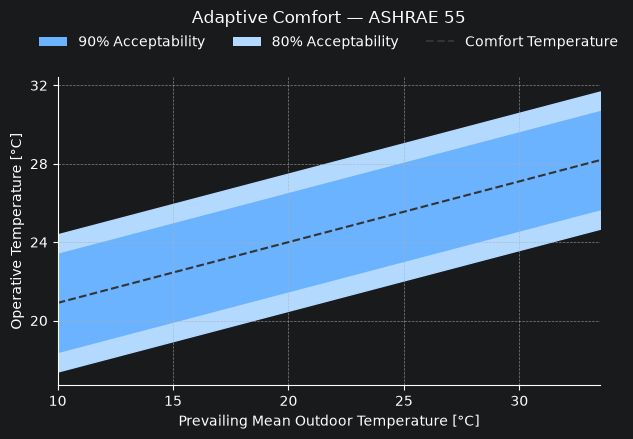

In [2]:
ashrae_result = (
    AdaptivePlot(model_func=adaptive_ashrae)
    .set_params(v=0.1)
    .plot(title="Adaptive Comfort — ASHRAE 55")
)
plt.show()

## 2. EN 16798 — Default Chart

EN 16798 defines three categories (I, II, III) with progressively wider bands. Category I represents the strictest comfort requirement.

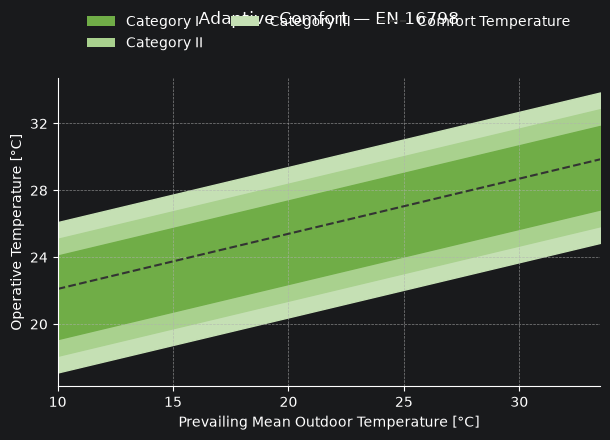

In [3]:
en_result = (
    AdaptivePlot(model_func=adaptive_en)
    .set_params(v=0.1)
    .plot(title="Adaptive Comfort — EN 16798")
)
plt.show()

## 3. Selecting Specific Bands

Pass a list of band keys to `set_regions(show=...)` to display only the bands you need. ASHRAE 55 uses `'80'` and `'90'` for 80 % and 90 % acceptability. EN 16798 uses `'cat_i'`, `'cat_ii'`, `'cat_iii'`.

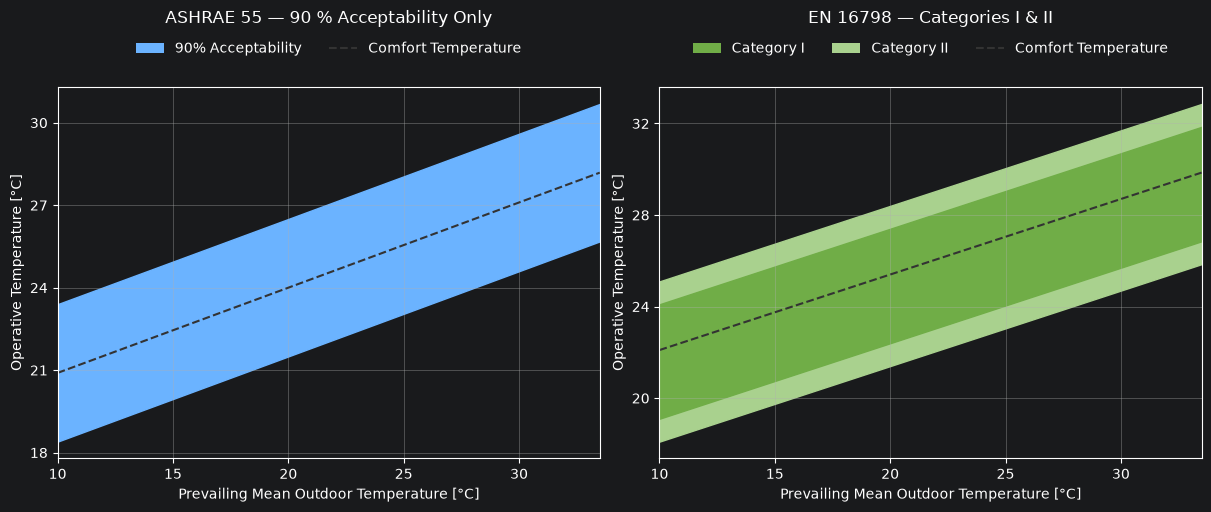

In [4]:
fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)

(
    AdaptivePlot(model_func=adaptive_ashrae)
    .set_params(v=0.1)
    .set_regions(show=["90"])
    .plot(ax=ax0, title="ASHRAE 55 — 90 % Acceptability Only")
)

(
    AdaptivePlot(model_func=adaptive_en)
    .set_params(v=0.1)
    .set_regions(show=["cat_i", "cat_ii"])
    .plot(ax=ax1, title="EN 16798 — Categories I & II")
)

plt.show()

## 4. Custom Labels and Colors

Band labels and colors can be overridden by passing `labels` and `colors` to `set_regions`. The list length must match the number of bands shown.

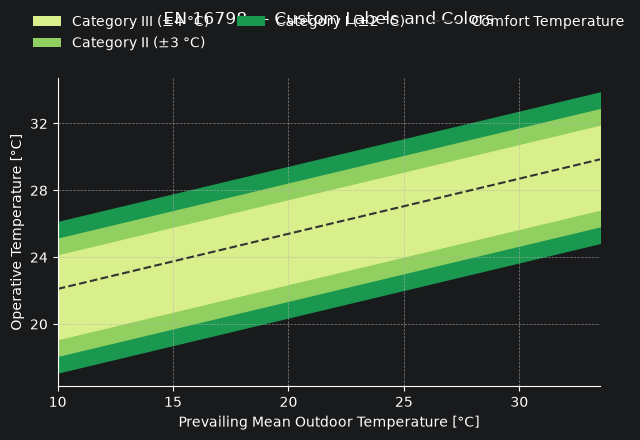

In [5]:
en_custom = (
    AdaptivePlot(model_func=adaptive_en)
    .set_params(v=0.1)
    .set_regions(
        show=["cat_i", "cat_ii", "cat_iii"],
        labels=["Category I (±2 °C)", "Category II (±3 °C)", "Category III (±4 °C)"],
        colors=["#1a9850", "#91cf60", "#d9ef8b"],
    )
    .plot(title="EN 16798 — Custom Labels and Colors")
)
plt.show()

## 5. Reusable Band Configuration with RegionsConfig

`RegionsConfig` stores a band selection with optional custom labels and colors. Create it once and pass it to `set_regions(show=config)` to reuse the same definition across multiple plots.

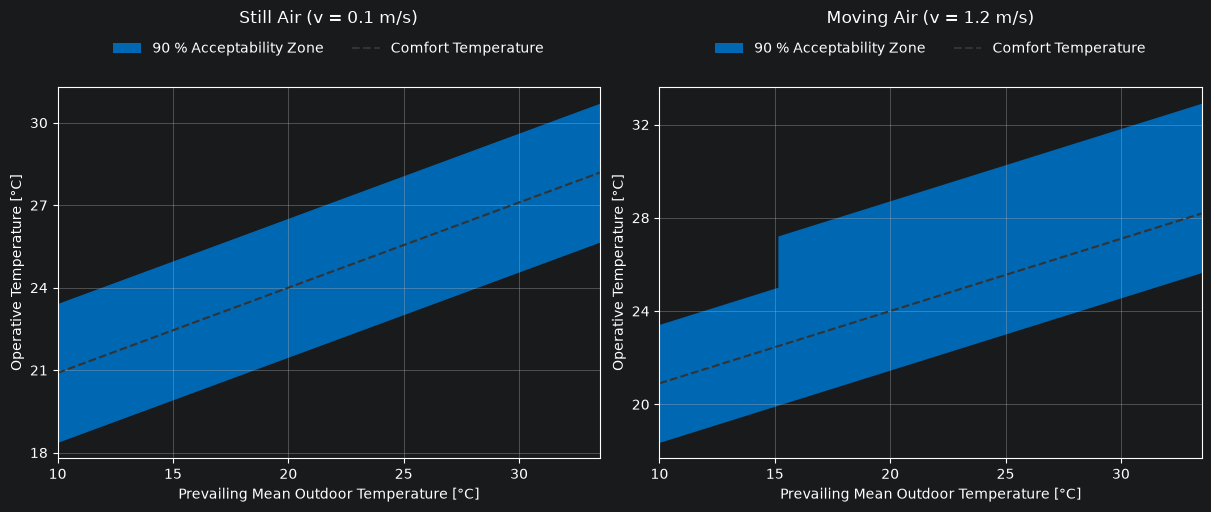

In [6]:
ashrae_config = RegionsConfig(
    show=["90"],
    labels=["90 % Acceptability Zone"],
    colors=["#0067B2"],
)

fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)

AdaptivePlot(model_func=adaptive_ashrae).set_params(v=0.1).set_regions(
    show=ashrae_config
).plot(ax=ax0, title="Still Air (v = 0.1 m/s)")
AdaptivePlot(model_func=adaptive_ashrae).set_params(v=1.2).set_regions(
    show=ashrae_config
).plot(ax=ax1, title="Moving Air (v = 1.2 m/s)")

plt.show()

## 6. Cooling Effect: Still Air vs Elevated Air Speed

When `v ≥ 0.6 m/s` and operative temperature exceeds 25 °C, the model shifts the upper comfort boundary upward. The side-by-side comparison shows the practical benefit of ceiling fans or natural cross-ventilation in warm climates.

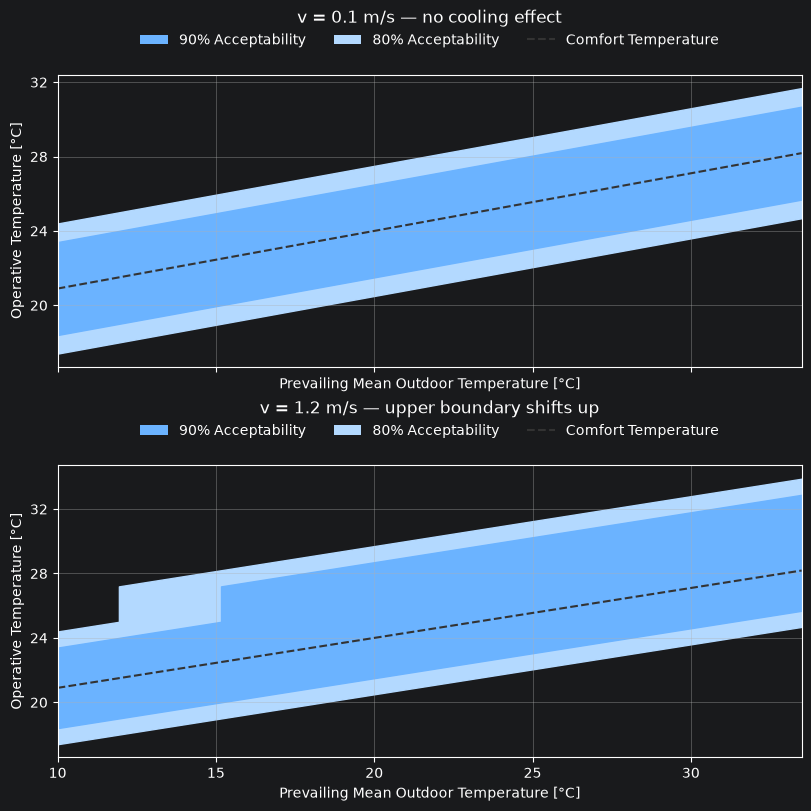

In [7]:
fig, (ax0, ax1) = plt.subplots(
    2, 1, figsize=(8, 8), constrained_layout=True, sharex=True
)

AdaptivePlot(model_func=adaptive_ashrae).set_params(v=0.1).plot(
    ax=ax0, title="v = 0.1 m/s — no cooling effect"
)
AdaptivePlot(model_func=adaptive_ashrae).set_params(v=1.2).plot(
    ax=ax1, title="v = 1.2 m/s — upper boundary shifts up"
)

plt.show()

## 7. Returned Artists and Scatter Overlays

`result.ax` is the Matplotlib `Axes` with all the standard methods. Use it to overlay measured operative temperatures on the chart.

The chart is drawn with one fixed air speed from `set_params(v=...)`. If overlaid points were measured at different air speeds, points with higher air speed can look less comfortable on the chart than the adaptive model says they are, because the plotted band receives the elevated-air-speed cooling effect only for the single `v` used to draw the chart.


Still air (v=0.1): 28.1 False
Moving air (v=1.2): 30.3 True


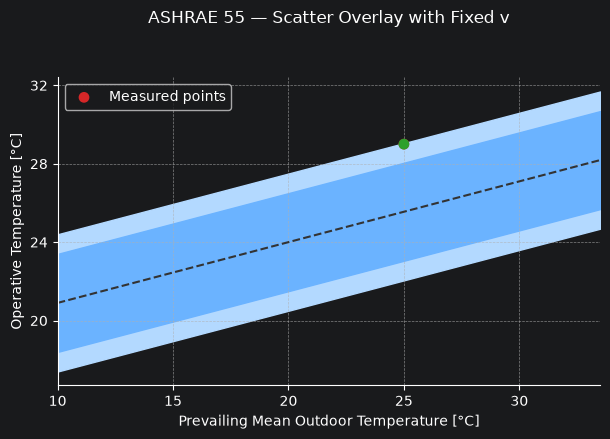

In [8]:
still_air = adaptive_ashrae(tdb=29, tr=29, t_running_mean=25, v=0.1)
moving_air = adaptive_ashrae(tdb=29, tr=29, t_running_mean=25, v=1.2)

print("Still air (v=0.1):", still_air.tmp_cmf_90_up, still_air.acceptability_90)
print("Moving air (v=1.2):", moving_air.tmp_cmf_90_up, moving_air.acceptability_90)

result = (
    AdaptivePlot(model_func=adaptive_ashrae)
    .set_params(v=0.1)  # only matches the first point
    .plot(title="ASHRAE 55 — Scatter Overlay with Fixed v")
)

# Both points land at the same chart location, but only the first point
# was measured at the chart air speed. The green point is comfortable per
# adaptive_ashrae(..., v=1.2), but appears above the fixed-v 90% boundary.
result.ax.scatter(
    [25, 25],
    [29, 29],
    c=["tab:red", "tab:green"],
    s=45,
    zorder=5,
    label="Measured points",
)
result.ax.legend(loc="lower center", bbox_to_anchor=(0.5, 1.02), ncol=2)
result.ax.set_title("ASHRAE 55 — Scatter Overlay with Fixed v", y=1.22)
plt.show()